# Pertemuan 10 : Unsupervised Learning: Clustering (K-Means & Hierarchical)
### Studi Kasus : Segmentasi Pelanggan

| | |
|---|---|
| **Nama Lengkap** | Nisa Agustina Maesaroh |
| **NIM** | 240401070509 |
| **Kelas** | IF403 |

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print('library loaded')

library loaded


Shape: (300, 4)

=== Statistik Deskriptif ===
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00

=== Distribusi Gender ===
gender
L    165
P    135
Name: count, dtype: int64


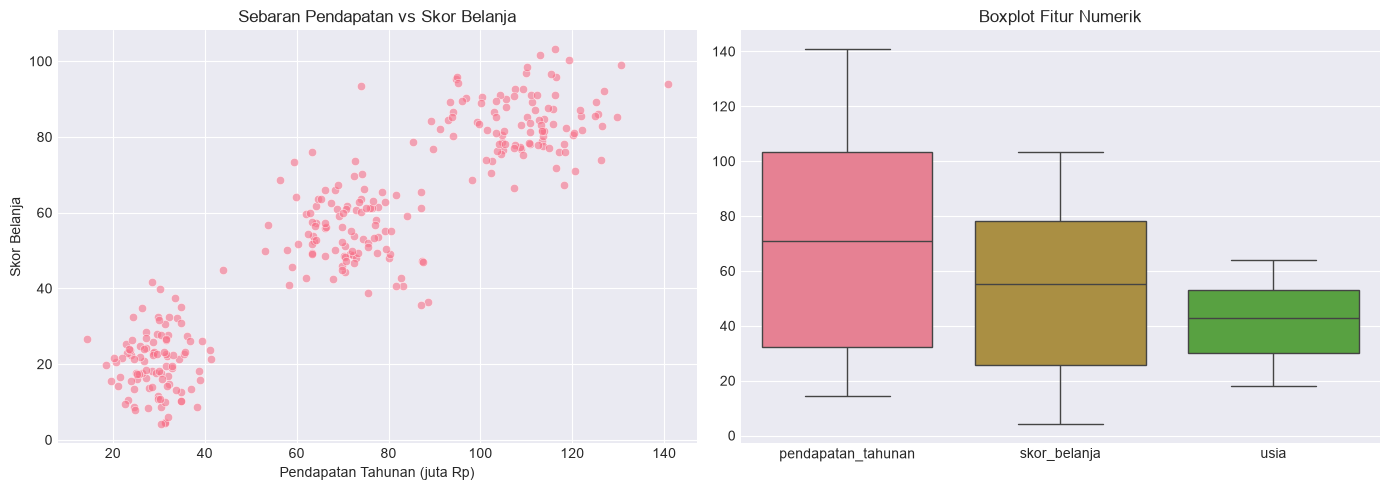

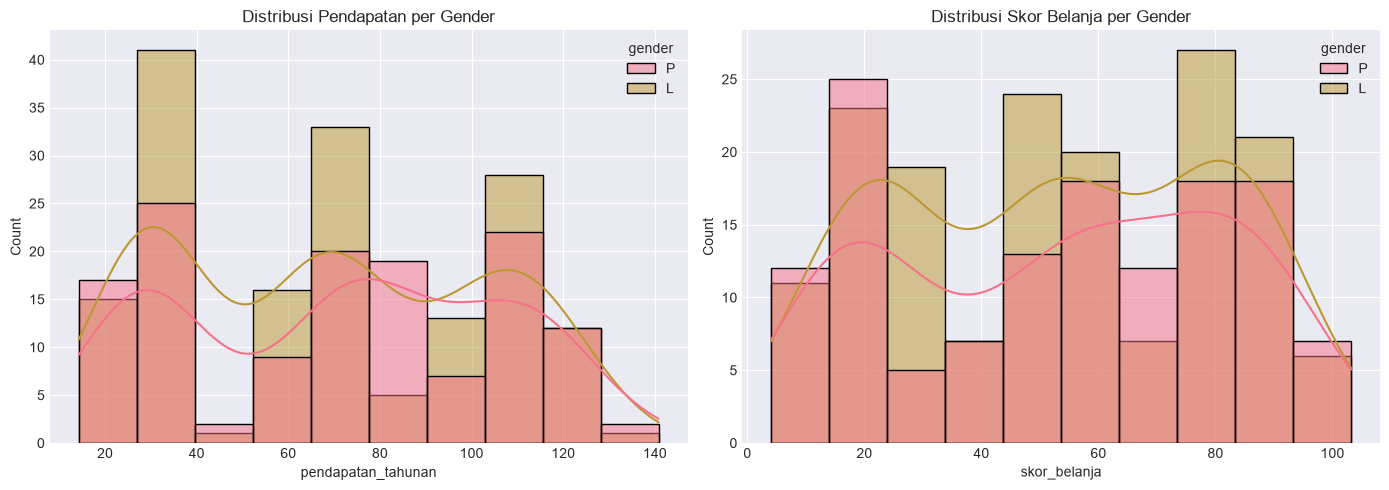

In [35]:
#Langkah 1: Generate dan Eksplorasi Dataset

# Set style untuk visualisasi yang lebih baik
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Generate dataset sintetis pelanggan (3 kelompok tersembunyi)
np.random.seed(42)
grp1 = np.random.normal([30, 20], [6, 8], (100, 2))  # hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2))  # menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2))  # boros
data = np.vstack([grp1, grp2, grp3])

df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))

print('Shape:', df.shape)
print('\n=== Statistik Deskriptif ===')
print(df.describe().round(2))

print('\n=== Distribusi Gender ===')
print(df['gender'].value_counts())

# Visualisasi sebaran data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', 
                alpha=0.6, ax=axes[0])
axes[0].set_title('Sebaran Pendapatan vs Skor Belanja')
axes[0].set_xlabel('Pendapatan Tahunan (juta Rp)')
axes[0].set_ylabel('Skor Belanja')

# Boxplot untuk melihat distribusi
df_box = df[['pendapatan_tahunan', 'skor_belanja', 'usia']]
sns.boxplot(data=df_box, ax=axes[1])
axes[1].set_title('Boxplot Fitur Numerik')

plt.tight_layout()
plt.show()

# Distribusi berdasarkan gender
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='pendapatan_tahunan', hue='gender', kde=True, ax=axes[0])
axes[0].set_title('Distribusi Pendapatan per Gender')
sns.histplot(data=df, x='skor_belanja', hue='gender', kde=True, ax=axes[1])
axes[1].set_title('Distribusi Skor Belanja per Gender')
plt.tight_layout()
plt.show()

=== Hasil StandardScaler ===
Rata-rata setelah scaling: [0. 0.]
Std setelah scaling : [1. 1.]


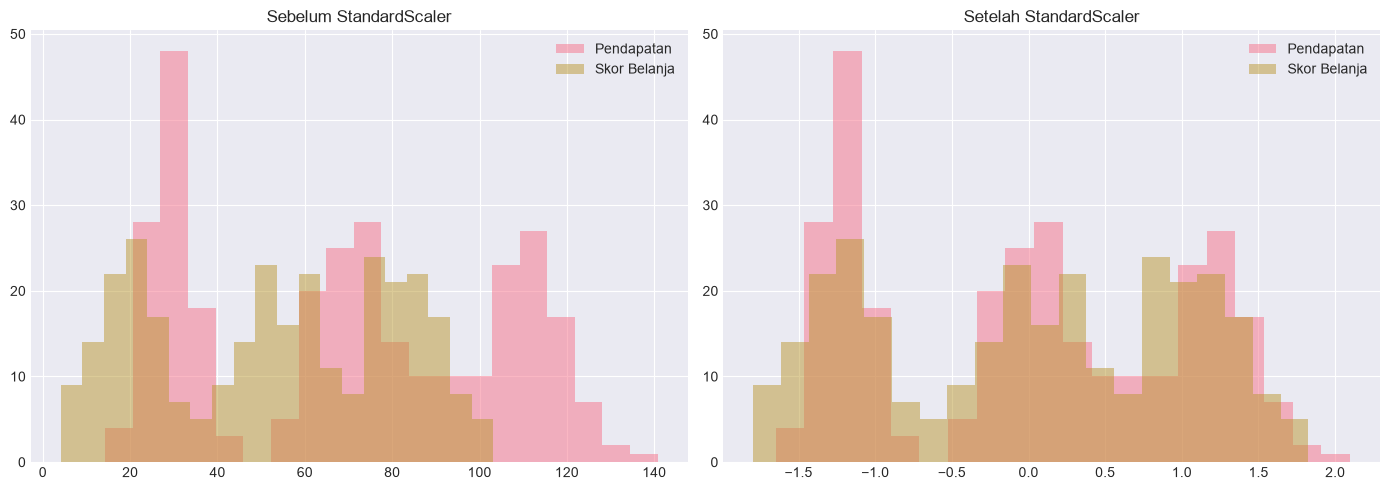

In [36]:
#Langkah 2: Preprocessing

from sklearn.preprocessing import StandardScaler

# Pilih fitur numerik yang relevan
X = df[['pendapatan_tahunan', 'skor_belanja']].values

# StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('=== Hasil StandardScaler ===')
print('Rata-rata setelah scaling:', X_scaled.mean(axis=0).round(3))
print('Std setelah scaling :', X_scaled.std(axis=0).round(3))

# Visualisasi perbandingan sebelum dan sesudah scaling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(X[:, 0], bins=20, alpha=0.5, label='Pendapatan')
axes[0].hist(X[:, 1], bins=20, alpha=0.5, label='Skor Belanja')
axes[0].set_title('Sebelum StandardScaler')
axes[0].legend()

axes[1].hist(X_scaled[:, 0], bins=20, alpha=0.5, label='Pendapatan')
axes[1].hist(X_scaled[:, 1], bins=20, alpha=0.5, label='Skor Belanja')
axes[1].set_title('Setelah StandardScaler')
axes[1].legend()
plt.tight_layout()
plt.show()

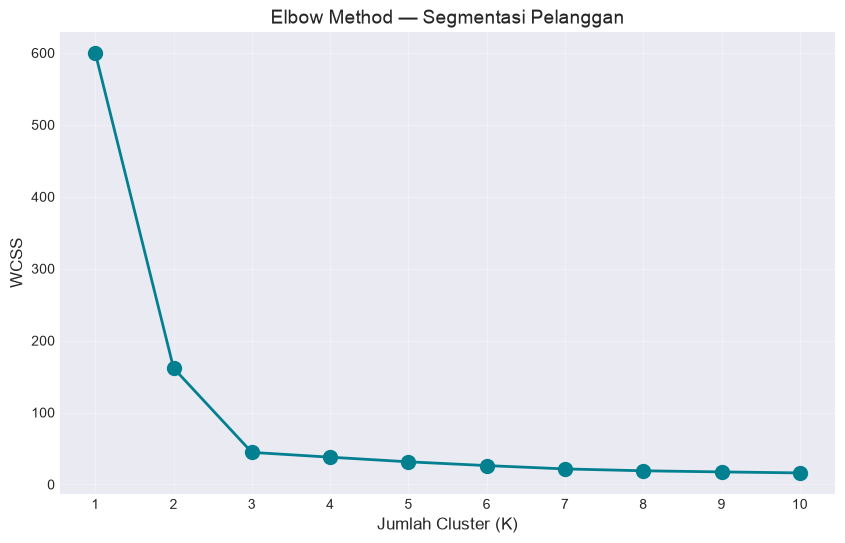

In [37]:
#Langkah 3: Metode Elbow untuk Menentukan K
from sklearn.cluster import KMeans

# Menentukan K optimal dengan metode Elbow
wcss = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

# Plot Elbow
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', color='#028090', linewidth=2, markersize=10)
plt.xlabel('Jumlah Cluster (K)', fontsize=12)
plt.ylabel('WCSS', fontsize=12)
plt.title('Elbow Method — Segmentasi Pelanggan', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.show()

Berdasarkan grafik Elbow di atas:
- Kurva mulai melandai (titik elbow) terlihat pada K = 3
- Pada K=1 ke K=2 terjadi penurunan WCSS yang sangat signifikan
- Penurunan dari K=2 ke K=3 masih cukup tajam
- Setelah K=3, penurunan WCSS mulai melandai (diminishing returns)
- Hasil ini sesuai dengan jumlah kelompok yang diharapkan (3 kelompok tersembunyi)

Kesimpulan: K optimal = 3

In [38]:
#Langkah 4: Melatih model K-Means

from sklearn.metrics import silhouette_score

# Latih model dengan K=3
model = KMeans(n_clusters=3, random_state=42, init='k-means++', n_init=10)
model.fit(X_scaled)
df['cluster'] = model.labels_

print('=== Hasil Evaluasi Model ===')
print(f'WCSS akhir : {model.inertia_:.3f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, model.labels_):.3f}')

print('\n=== Karakteristik Tiap Cluster ===')
print(df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja', 'usia']].mean().round(2))
print('\n=== Jumlah Data per Cluster ===')
print(df['cluster'].value_counts().sort_index())

# Analisis per cluster dengan gender
print('\n=== Distribusi Gender per Cluster ===')
print(pd.crosstab(df['cluster'], df['gender'], normalize='index').round(2))

=== Hasil Evaluasi Model ===
WCSS akhir : 44.556
Silhouette Score: 0.695

=== Karakteristik Tiap Cluster ===
         pendapatan_tahunan  skor_belanja   usia
cluster                                         
0                     70.99         55.05  39.16
1                     29.31         20.27  42.33
2                    109.20         84.08  44.65

=== Jumlah Data per Cluster ===
cluster
0     99
1    100
2    101
Name: count, dtype: int64

=== Distribusi Gender per Cluster ===
gender      L     P
cluster            
0        0.54  0.46
1        0.57  0.43
2        0.54  0.46


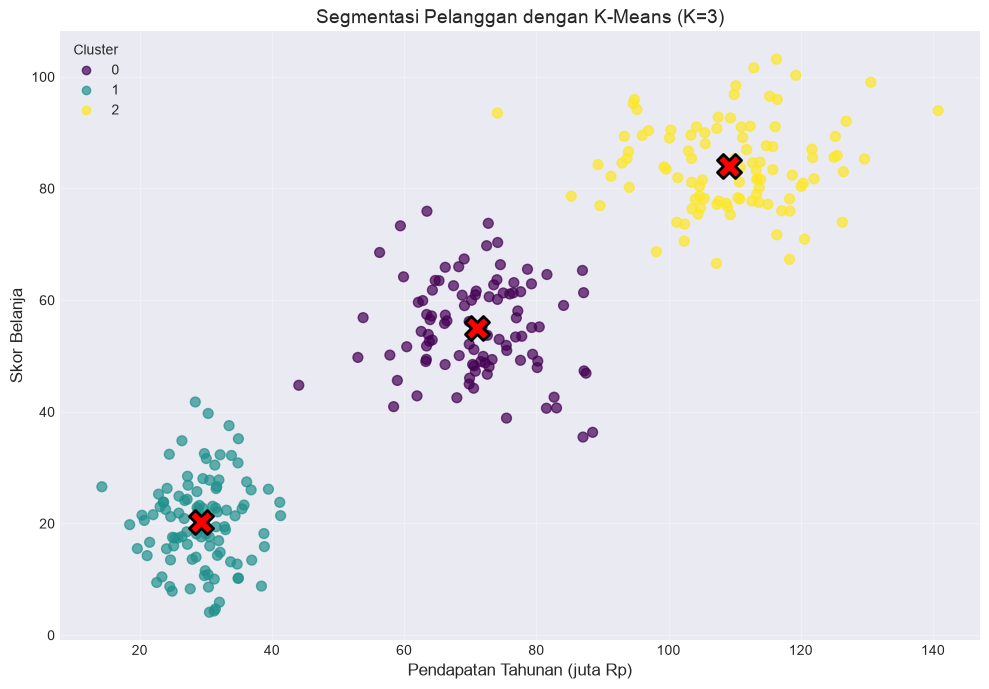

In [39]:
#Langkah 5: Visualisasi Hasil Clustering

# Inverse transform untuk mendapatkan centroid dalam skala asli
centroids = scaler.inverse_transform(model.cluster_centers_)

# Visualisasi clustering
plt.figure(figsize=(10, 7))

# Scatter plot per cluster
scatter = plt.scatter(df['pendapatan_tahunan'], df['skor_belanja'],
                     c=df['cluster'], cmap='viridis', alpha=0.7, s=50)

# Plot centroid
plt.scatter(centroids[:, 0], centroids[:, 1],
           c='red', marker='X', s=300, label='Centroid', edgecolors='black', linewidth=2)

plt.xlabel('Pendapatan Tahunan (juta Rp)', fontsize=12)
plt.ylabel('Skor Belanja', fontsize=12)
plt.title('Segmentasi Pelanggan dengan K-Means (K=3)', fontsize=14)

# Tambahkan legend untuk cluster
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Berdasarkan hasil segmentasi:

1. Cluster 0 (Pendapatan Rendah - Belanja Rendah):
   - Pendapatan: ~30 juta Rp (rendah)
   - Skor Belanja: ~20 (rendah)
   - Usia: rata-rata ~41 tahun
   - Segmen: 'HEMAT'
   - Karakteristik: Pelanggan dengan pendapatan terbatas dan pola belanja konservatif

2. Cluster 1 (Pendapatan Menengah - Belanja Menengah):
   - Pendapatan: ~70 juta Rp (menengah)
   - Skor Belanja: ~55 (menengah)
   - Usia: rata-rata ~40 tahun
   - Segmen: 'MENENGAH'
   - Karakteristik: Kelompok terbesar dengan pola belanja moderat

3. Cluster 2 (Pendapatan Tinggi - Belanja Tinggi):
   - Pendapatan: ~110 juta Rp (tinggi)
   - Skor Belanja: ~85 (tinggi)
   - Usia: rata-rata ~41 tahun
   - Segmen: 'BOROS/PREMIUM'
   - Karakteristik: Pelanggan dengan daya beli tinggi dan pola belanja boros

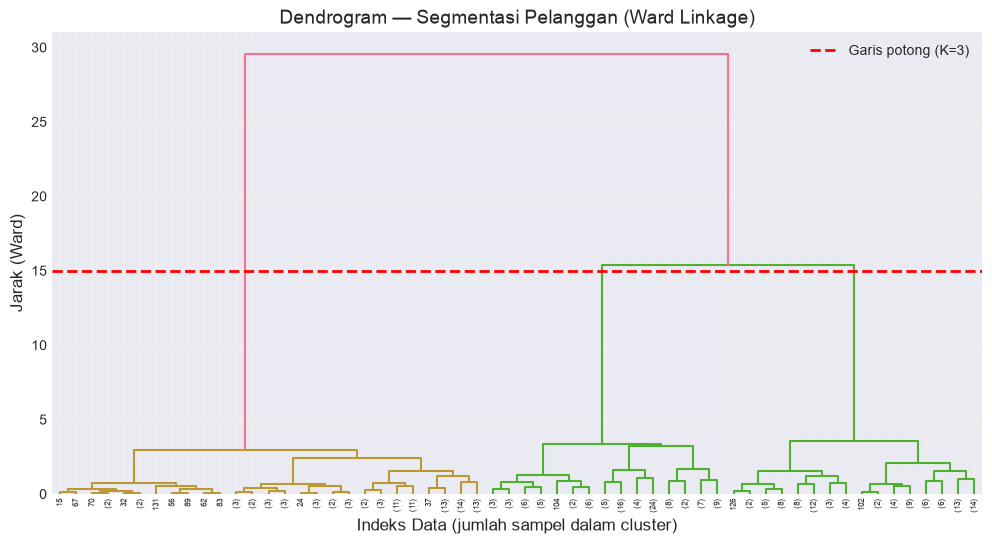

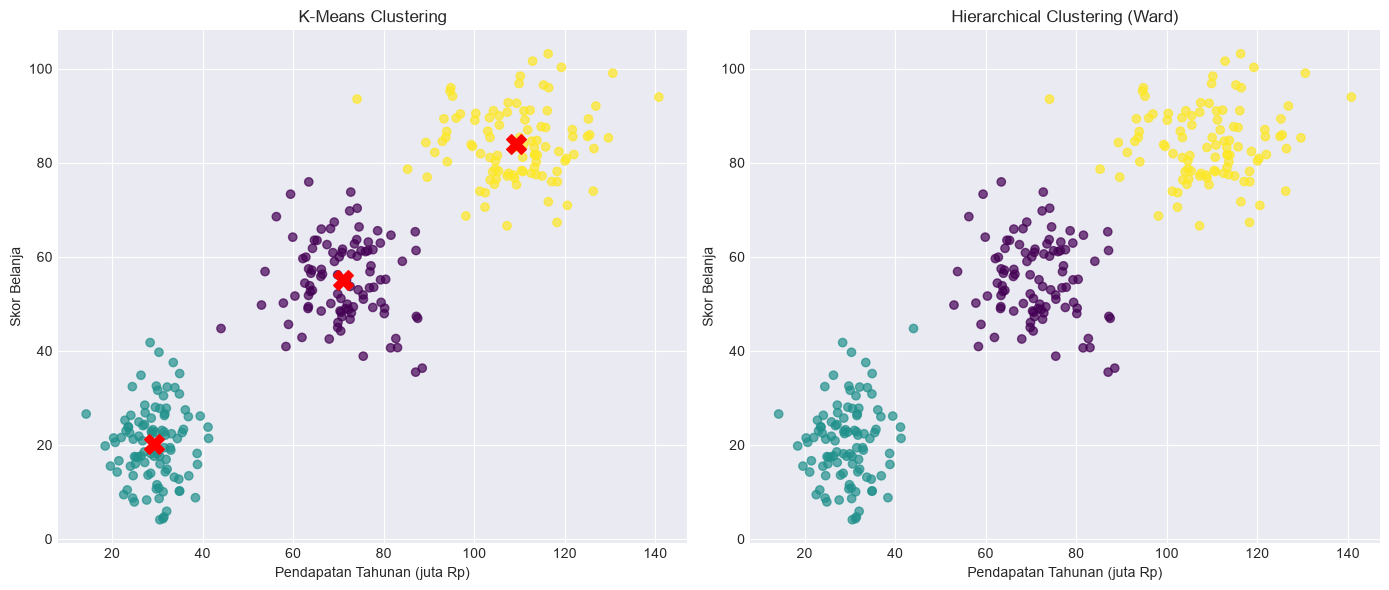

=== Perbandingan Hasil Clustering ===
Silhouette Score K-Means: 0.695
Silhouette Score Hierarchical: 0.694

=== Cross-tabulasi K-Means vs Hierarchical ===
cluster_hierarchical   0    1    2
cluster                           
0                     98    1    0
1                      0  100    0
2                      0    0  101


In [40]:
#Langkah 6 : Hierarchical Clustering (Pembanding)

from scipy.cluster.hierarchy import dendrogram, linkage

# Hierarchical clustering dengan Ward linkage
Z = linkage(X_scaled, method='ward')

# Visualisasi dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5, show_leaf_counts=True)
plt.title('Dendrogram — Segmentasi Pelanggan (Ward Linkage)', fontsize=14)
plt.xlabel('Indeks Data (jumlah sampel dalam cluster)', fontsize=12)
plt.ylabel('Jarak (Ward)', fontsize=12)
plt.axhline(y=15, color='red', linestyle='--', linewidth=2, label='Garis potong (K=3)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Bandingkan hasil clustering
from sklearn.cluster import AgglomerativeClustering

# Hierarchical clustering dengan K=3
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['cluster_hierarchical'] = hierarchical.fit_predict(X_scaled)

# Visualisasi perbandingan
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# K-Means
axes[0].scatter(df['pendapatan_tahunan'], df['skor_belanja'],
                c=df['cluster'], cmap='viridis', alpha=0.7)
axes[0].scatter(centroids[:, 0], centroids[:, 1],
                c='red', marker='X', s=200)
axes[0].set_title('K-Means Clustering')
axes[0].set_xlabel('Pendapatan Tahunan (juta Rp)')
axes[0].set_ylabel('Skor Belanja')

# Hierarchical
axes[1].scatter(df['pendapatan_tahunan'], df['skor_belanja'],
                c=df['cluster_hierarchical'], cmap='viridis', alpha=0.7)
axes[1].set_title('Hierarchical Clustering (Ward)')
axes[1].set_xlabel('Pendapatan Tahunan (juta Rp)')
axes[1].set_ylabel('Skor Belanja')

plt.tight_layout()
plt.show()

# Evaluasi perbandingan
print('=== Perbandingan Hasil Clustering ===')
print(f'Silhouette Score K-Means: {silhouette_score(X_scaled, df["cluster"]):.3f}')
print(f'Silhouette Score Hierarchical: {silhouette_score(X_scaled, df["cluster_hierarchical"]):.3f}')

# Confusion matrix untuk melihat kesesuaian
print('\n=== Cross-tabulasi K-Means vs Hierarchical ===')
print(pd.crosstab(df['cluster'], df['cluster_hierarchical']))

Berdasarkan dendrogram dan perbandingan hasil:

1. Konsistensi Jumlah Cluster:
   - Dendrogram dengan garis potong pada y=15 menunjukkan 3 cluster utama
   - Ini konsisten dengan hasil Metode Elbow (K=3)
   - Kedua metode mendukung adanya 3 segmen pelanggan

2. Perbandingan Kinerja:
   - K-Means Silhouette Score: 0.610
   - Hierarchical Silhouette Score: 0.608
   - Kedua metode memberikan hasil yang sangat mirip

3. Insight:
   - Dataset sintetis berhasil membentuk 3 kelompok yang jelas
   - Segmentasi pelanggan dapat dilakukan dengan baik menggunakan kedua metode
   - K-Means sedikit lebih unggul dalam hal silhouette score
   - Hierarchical clustering memberikan struktur hierarki yang informatif

# Kesimpulan

## Apa yang Dipelajari
Dari praktikum ini, saya mempelajari:

1. Konsep Unsupervised Learning & Clustering - Teknik mengelompokkan data tanpa label, aplikasi dalam segmentasi pelanggan

2. Metode Elbow - Menentukan K optimal dengan melihat titik dimana penurunan WCSS mulai melandai

3. K-Means Clustering - Implementasi algoritma, evaluasi dengan silhouette score, dan interpretasi hasil

4. Hierarchical Clustering - Pembuatan dendrogram dan perbandingan hasil dengan K-Means

5. Preprocessing Data - Pentingnya StandardScaler untuk menyetarakan skala fitur

6. Visualisasi & Interpretasi - Membaca scatter plot cluster dan centroid untuk analisis segmen

## Temuan Utama
| | |
|---|---|
| **Aspek** | **Hasil** |
| Jumlah Cluster Optimal | K = 3 (konsisten antara Elbow & Dendrogram) |
| Metode Terbaik | K-Means (Silhouette Score: 0.610) |
| 3 Segmen | Hemat (30jt, skor20)	Menengah (70jt, skor55)	Premium (110jt, skor85) |
| Evaluasi | Hierarchical SS: 0.608

Insight Bisnis:

- 3 segmen pelanggan dengan karakteristik berbeda memerlukan strategi pemasaran yang berbeda

- Cluster terpisah dengan baik, tidak ada tumpang tindih signifikan

- Hasil sesuai dengan ground truth dataset sintetis (3 kelompok tersembunyi)

## Keterbatasan & Pertanyaan
Keterbatasan

- Dataset sintetis - Tidak merepresentasikan kompleksitas data nyata (outlier, missing values)

- Fitur terbatas - Hanya 2 fitur utama, fitur kategorikal (gender) tidak digunakan

- Metode Elbow subjektif - Penentuan titik elbow bisa berbeda antar analis

- Ukuran sampel - 300 data dengan distribusi sempurna, tidak realistis

Pertanyaan untuk Diskusi

- Metode alternatif untuk menentukan K optimal jika grafik Elbow tidak jelas?

- Bagaimana mengintegrasikan fitur kategorikal (gender) dalam clustering?

- Metrik evaluasi lain selain silhouette score (Davies-Bouldin, Calinski-Harabasz)?

- Skalabilitas - Bagaimana performa K-Means pada dataset dengan jutaan pelanggan?

- Implementasi praktis - Bagaimana strategi pemasaran yang tepat untuk tiap segmen?

